In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [64]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/3-customersatisfaction.csv')
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [65]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [66]:
df.head()

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


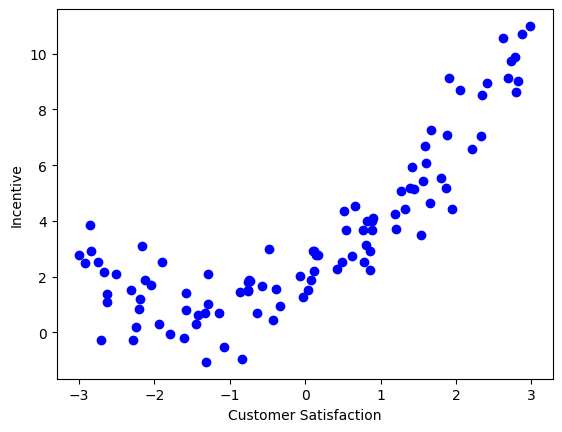

In [68]:
plt.scatter(df["Customer Satisfaction"] , df["Incentive"] , color="b")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Incentive")
plt.show()

In [69]:
#dependent ve independent features
X= df[["Customer Satisfaction"]]
y= df["Incentive"]
X.head()

,Customer Satisfaction
0,-1.282447
1,0.425298
2,1.953070
3,2.625838
4,-1.426333


In [70]:
y.head()

,Incentive
0,1.010513
1,2.281043
2,4.415053
3,10.563600
4,0.627365


In [71]:
#train - test split

In [72]:
X_train , X_test , y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [73]:
X_train

,Customer Satisfaction
99,0.512504
3,2.625838
20,-0.865714
55,-1.145369
6,2.823460
...,...
28,1.191020
0,-1.282447
5,-1.311432
12,0.490521


In [74]:
regresyon=LinearRegression()

In [75]:
#scaler
scaler=StandardScaler()

In [76]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [77]:
regresyon.fit(X_train,y_train)

LinearRegression()

In [78]:
#prediction

In [79]:
y_pred=regresyon.predict(X_test)

In [80]:
y_pred

array([ 4.65663741,  3.71913877,  1.64121789,  6.29646523,  3.46766736,
        5.7580845 ,  4.692485  ,  3.61616231,  5.62448003,  0.13472702,
        4.47909659,  4.8130839 ,  1.58319087,  0.30515983,  5.27634309,
        0.41711005, -0.7385295 , -0.32653914,  3.55906887,  1.19798631])

In [81]:
score=r2_score(y_test,y_pred)
print(score)

0.2705652535622246


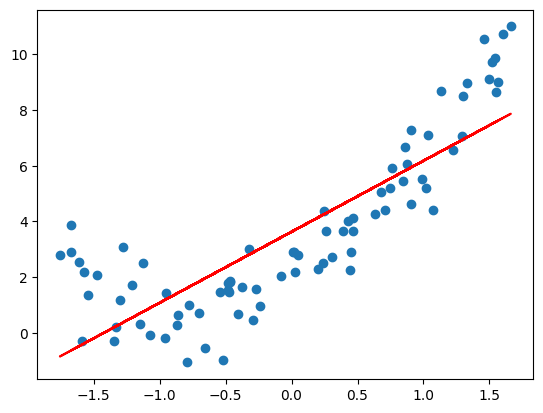

In [82]:
plt.scatter(X_train,y_train)
plt.plot(X_train, regresyon.predict(X_train),color="r")
plt.show()

In [83]:
#çıkan score kötü bir r2socre tabloya da bakınca çok net bir sonuç olmadığını görüp farklı bir regresyon uygulamaya geçmeliyiz ve r2score'u arttırmalıyız

In [84]:
poly=PolynomialFeatures(degree=2  , include_bias=True)

In [85]:
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [86]:
X_train_poly

array([[ 1.00000000e+00,  2.47633535e-01,  6.13223675e-02],
       [ 1.00000000e+00,  1.45565669e+00,  2.11893639e+00],
       [ 1.00000000e+00, -5.40182671e-01,  2.91797318e-01],
       [ 1.00000000e+00, -7.00039198e-01,  4.90054879e-01],
       [ 1.00000000e+00,  1.56862116e+00,  2.46057233e+00],
       [ 1.00000000e+00,  9.87568378e-01,  9.75291302e-01],
       [ 1.00000000e+00,  4.48640749e-01,  2.01278522e-01],
       [ 1.00000000e+00,  1.54377517e+00,  2.38324178e+00],
       [ 1.00000000e+00,  1.33219938e+00,  1.77475518e+00],
       [ 1.00000000e+00, -4.80410926e-01,  2.30794658e-01],
       [ 1.00000000e+00,  3.92892957e-01,  1.54364876e-01],
       [ 1.00000000e+00, -6.57456685e-01,  4.32249293e-01],
       [ 1.00000000e+00,  4.42663768e-01,  1.95951211e-01],
       [ 1.00000000e+00, -8.72131603e-01,  7.60613533e-01],
       [ 1.00000000e+00, -1.57257044e+00,  2.47297780e+00],
       [ 1.00000000e+00, -4.70184630e-01,  2.21073587e-01],
       [ 1.00000000e+00, -8.36083500e-02

In [87]:
regresyon.fit(X_train_poly,y_train)

LinearRegression()

In [88]:
y_pred=regresyon.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.7685687698788557


In [89]:
#artmış

In [90]:
regresyon.coef_

array([0.        , 2.63871762, 1.54959954])

In [91]:
regresyon.intercept_

np.float64(2.076676429793281)

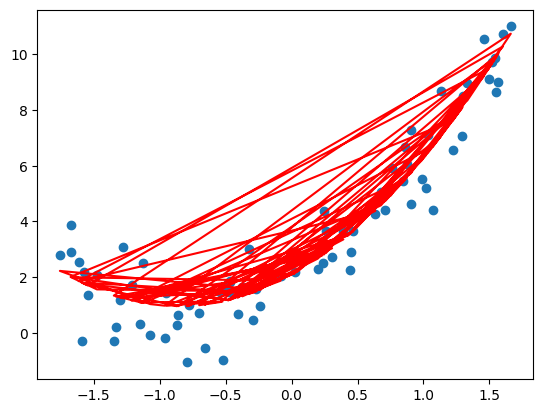

In [92]:
plt.scatter(X_train,y_train)
plt.plot(X_train, regresyon.predict(X_train_poly),color="r")
plt.show()

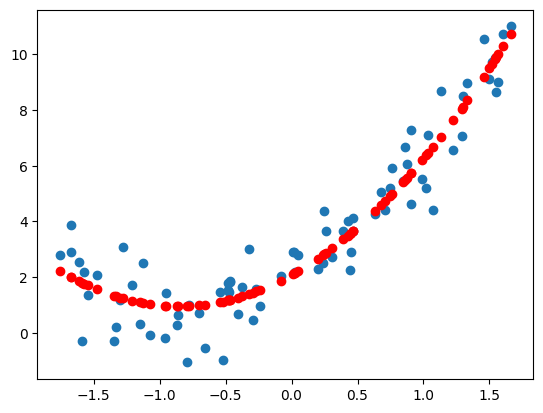

In [93]:
plt.scatter(X_train,y_train)
plt.scatter(X_train, regresyon.predict(X_train_poly),color="r")
plt.show()

In [94]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.757344362140105


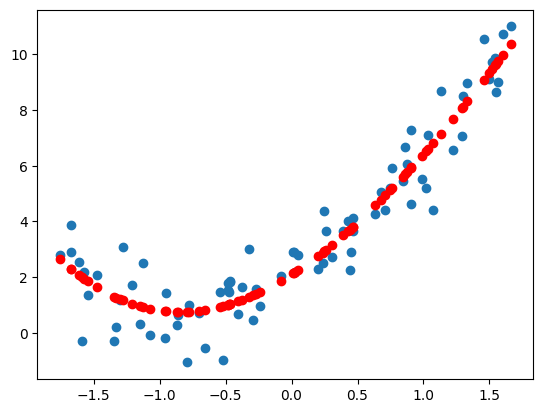

In [95]:
plt.scatter(X_train, y_train)
plt.scatter(X_train, regression.predict(X_train_poly), color = "r")
plt.show()


In [96]:
#polimal regresyonda 0.27den 0.76ya çıktı bu iyi bir yükseliş ve kabul edilebilir bir sonuç
#degree=2 de 0.76 degree=3 de 0.75 çıktı

In [97]:
#new data
new_df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/3-newdatas.csv")

In [98]:
new_df

,0
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [99]:
new_df.rename(columns={"0":"Customer_Satisfaction"},inplace=True)

In [100]:
new_df

,Customer_Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [101]:
X_new=new_df[["Customer_Satisfaction"]]

In [102]:
X_new = scaler.fit_transform(X_new)

In [103]:
X_new_poly=poly.transform(X_new)

In [104]:
y_new =regression.predict(X_new_poly)

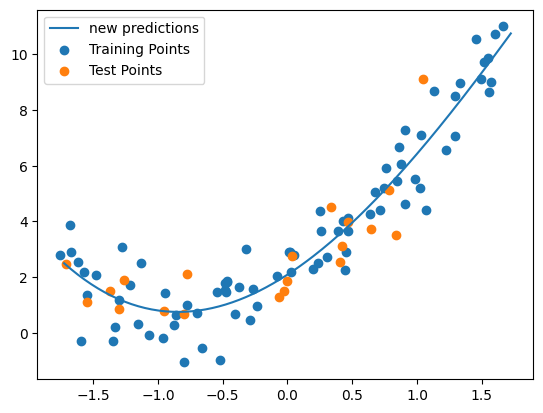

In [105]:
plt.plot(X_new, y_new, label="new predictions")
plt.scatter(X_train,y_train  , label="Training Points")
plt.scatter(X_test , y_test , label="Test Points")
plt.legend()
plt.show()

In [ ]:
#pipline
#polynomialFeatures,x_train_poly,regresyon gibi şeyleri profesyonel şekilde bir fonksiyonda art arda çalıştırmak için kurulan bir fonk

In [109]:
def poly_regression(degree):
    poly_features = PolynomialFeatures(degree=degree)
    lin_reg = LinearRegression()
    scaler = StandardScaler()
    pipeline = Pipeline([
        ("standard_scaler", scaler),
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print("R2 score: ", score)

    y_pred_new = pipeline.predict(X_new)
    plt.plot(X_new, y_pred_new, "r", label="New Predictions")
    plt.scatter(X_train, y_train, label="Training Points")
    plt.scatter(X_test, y_test, label="Test Points")
    plt.legend()
    plt.show()

R2 score:  0.2705652535622246


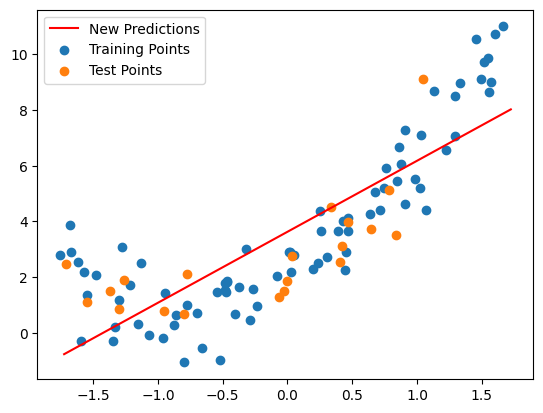

In [110]:
poly_regression(1)

R2 score:  0.7573443621401048


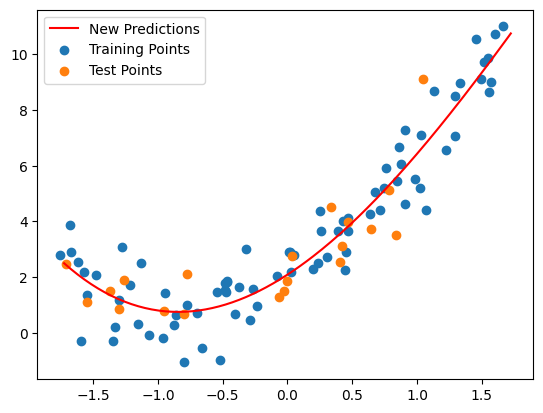

In [111]:
poly_regression(3)

R2 score:  0.2705652535622246


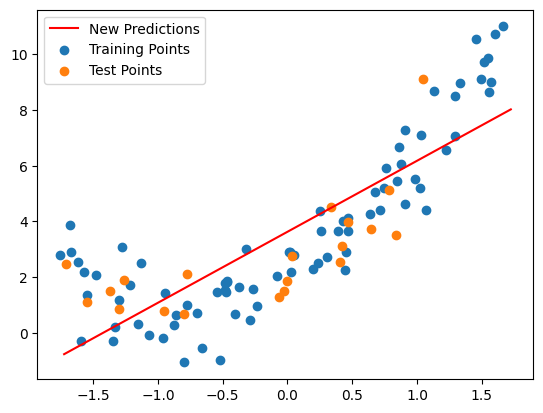

R2 score:  0.7685687698788557


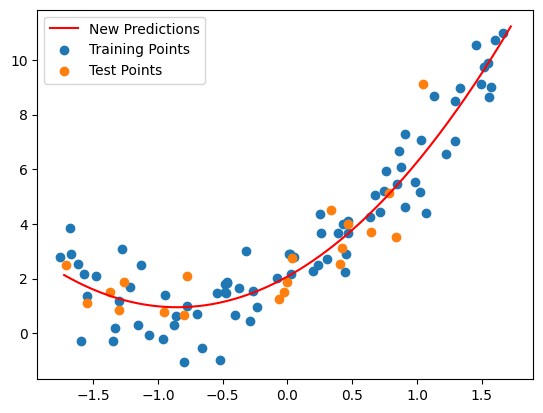

R2 score:  0.7573443621401048


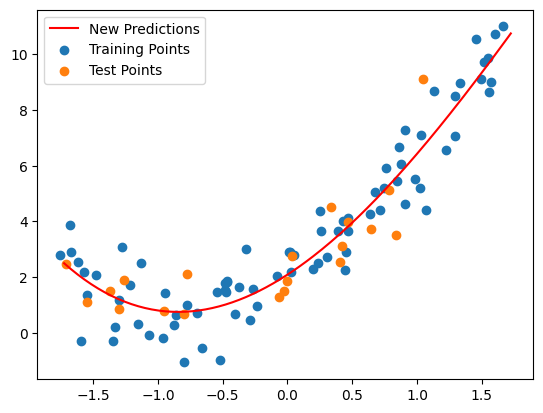

R2 score:  0.7355034443260413


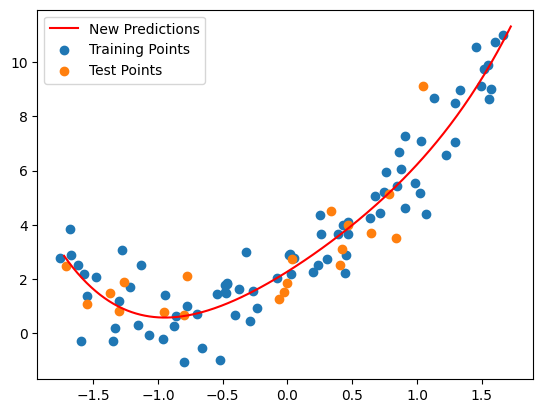

R2 score:  0.73512441650954


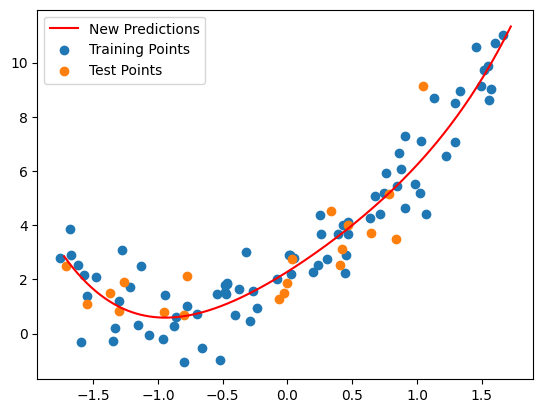

R2 score:  0.7343590482133435


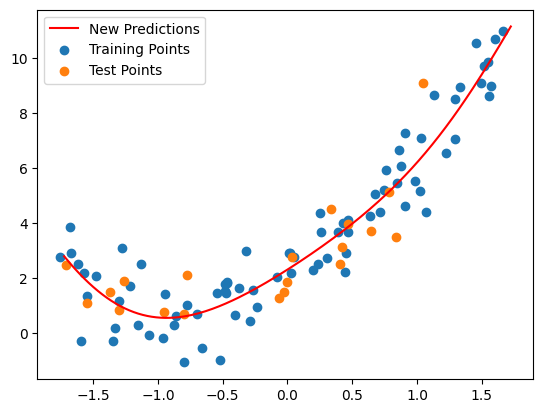

R2 score:  0.7347819263549452


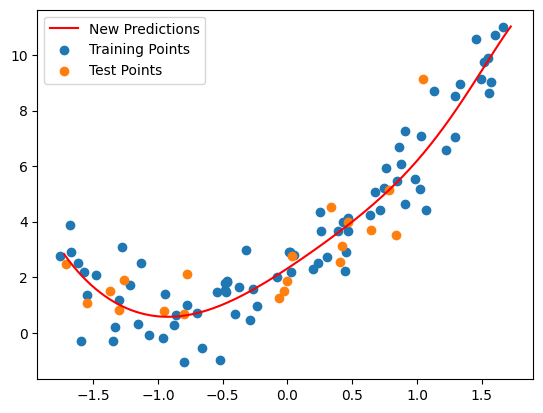

R2 score:  0.7411422099998375


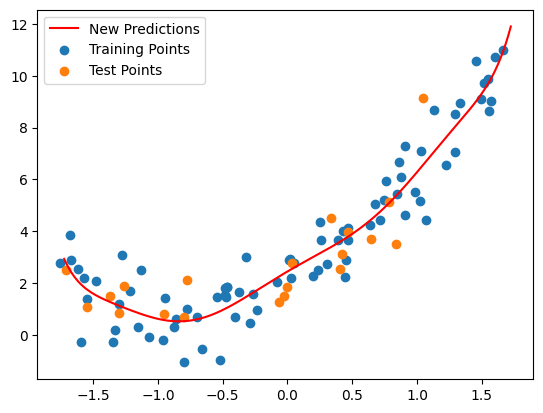

R2 score:  0.7310763879815911


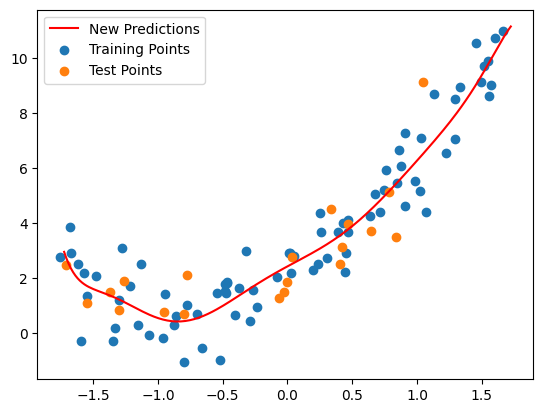

R2 score:  0.7280578621232836


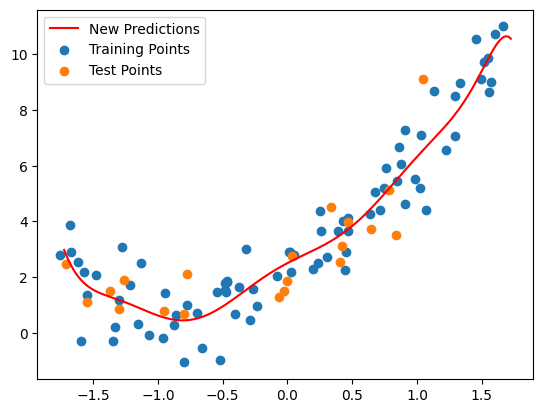

In [112]:
for degree in [1,2,3,4,5,6,7,8,9,10]:
    poly_regression(degree)